## Initialisation

In [3]:
%pip install pyspark pandas matplotlib seaborn

     ---------------------------------------- 0.0/455.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/455.4 MB ? eta -:--:--
     ---------------------------------------- 0.3/455.4 MB 2.9 MB/s eta 0:02:35
     ---------------------------------------- 0.7/455.4 MB 5.9 MB/s eta 0:01:18
     ---------------------------------------- 1.3/455.4 MB 7.4 MB/s eta 0:01:02
     ---------------------------------------- 1.9/455.4 MB 8.4 MB/s eta 0:00:54
     ---------------------------------------- 2.4/455.4 MB 9.1 MB/s eta 0:00:50
     ---------------------------------------- 3.0/455.4 MB 9.6 MB/s eta 0:00:48
     ---------------------------------------- 3.5/455.4 MB 9.6 MB/s eta 0:00:48
     ---------------------------------------- 3.9/455.4 MB 9.7 MB/s eta 0:00:47
     --------------------------------------- 4.4/455.4 MB 10.0 MB/s eta 0:00:46
     --------------------------------------- 4.9/455.4 MB 10.1 MB/s eta 0:00:45
     --------------------------------------- 5.3/455.4


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Cette cellule ne sert que si le nom du PC a des caractères non autorisés par Spark pour construire l'URL interne
# Elle ne sert qu'à contourner le problème en développement pour avoir un host local 

import os

os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("WorldCupAnalysis")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .getOrCreate()
)

print(spark.version)

4.1.2


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

spark = SparkSession.builder \
    .appName("WorldCupAnalysis") \
    .getOrCreate()

## Importation

In [3]:
root_folder = "data"

teams = spark.read.csv(root_folder + "/wc_2026_teams.csv", header=True, inferSchema=True)
fixtures = spark.read.csv(root_folder + "/wc_2026_fixtures.csv", header=True, inferSchema=True)
editions = spark.read.csv(root_folder + "/wc_all_editions.csv", header=True, inferSchema=True)
matches = spark.read.csv(root_folder + "/wc_all_matches.csv", header=True, inferSchema=True)
scorers = spark.read.csv(root_folder + "/wc_top_scorers.csv", header=True, inferSchema=True)

In [4]:
for df_name, df in {
    "teams": teams,
    "fixtures": fixtures,
    "editions": editions,
    "matches": matches,
    "scorers": scorers
}.items():
    print(f"\n=== {df_name} ===")
    df.printSchema()
    df.show(5)


=== teams ===
root
 |-- team: string (nullable = true)
 |-- group: string (nullable = true)
 |-- confederation: string (nullable = true)
 |-- fifa_rank: integer (nullable = true)
 |-- coach: string (nullable = true)
 |-- best_wc_result: string (nullable = true)
 |-- debut_2026: string (nullable = true)

+------------+-----+-------------+---------+--------------+--------------------+----------+
|        team|group|confederation|fifa_rank|         coach|      best_wc_result|debut_2026|
+------------+-----+-------------+---------+--------------+--------------------+----------+
|      Mexico|    A|     CONCACAF|       15|Javier Aguirre|Quarter-finals (1...|        No|
|South Africa|    A|          CAF|       60|    Hugo Broos|Group stage (1998...|        No|
| South Korea|    A|          AFC|       25| Hong Myung-bo|  Semi-finals (2002)|        No|
|     Czechia|    A|         UEFA|       41|    Ivan Hasek|Runner-up (1934,1...|        No|
|      Canada|    B|     CONCACAF|       30|  Jess

## Evolution du nombres d'équipes participantes

+----+-----+
|year|teams|
+----+-----+
|1930|   13|
|1934|   16|
|1938|   15|
|1950|   13|
|1954|   16|
|1958|   16|
|1962|   16|
|1966|   16|
|1970|   16|
|1974|   16|
|1978|   16|
|1982|   24|
|1986|   24|
|1990|   24|
|1994|   24|
|1998|   32|
|2002|   32|
|2006|   32|
|2010|   32|
|2014|   32|
+----+-----+
only showing top 20 rows


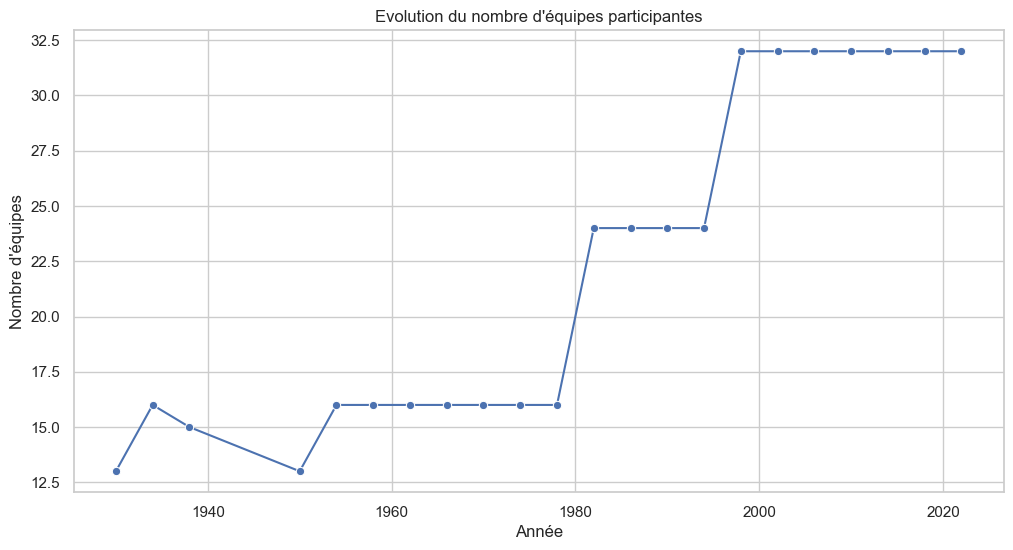

In [ ]:
editions.select("year", "teams").show()

pdf = pd.DataFrame(
    editions.select("year", "teams").collect(),
    columns=["year", "teams"]
)

plt.figure(figsize=(12,6))
sns.lineplot(data=pdf, x="year", y="teams", marker="o")

plt.title("Evolution du nombre d'équipes participantes")
plt.xlabel("Année")
plt.ylabel("Nombre d'équipes")
plt.show()

## Pays les plus titrés

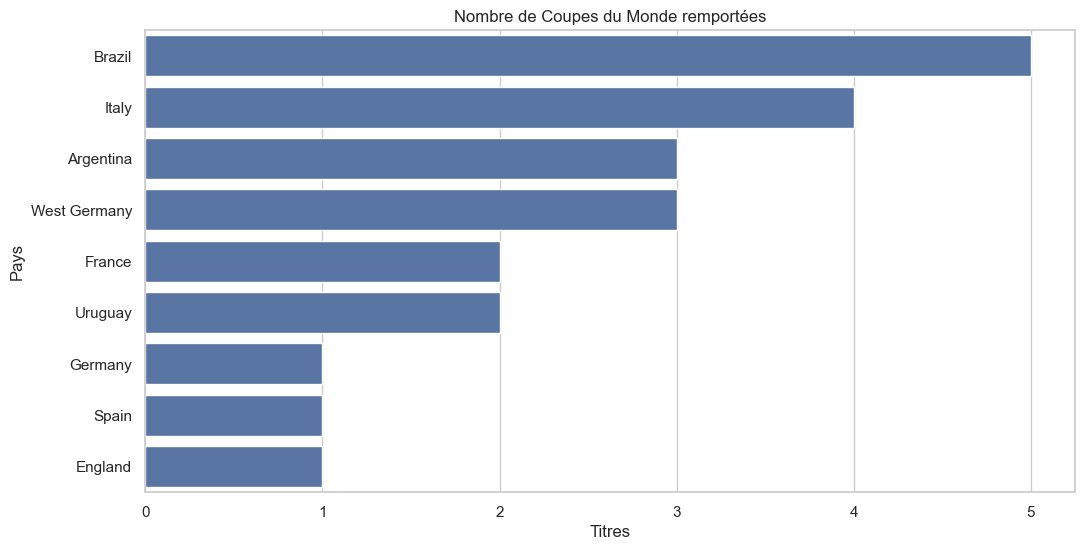

In [32]:
titles = editions.groupBy("champion") \
    .count() \
    .orderBy(desc("count"))

pdf = pd.DataFrame(
    [row.asDict() for row in titles.collect()]
)

plt.figure(figsize=(12,6))
sns.barplot(data=pdf,
            x="count",
            y="champion")

plt.title("Nombre de Coupes du Monde remportées")
plt.xlabel("Titres")
plt.ylabel("Pays")
plt.show()

## Répartition des titres par continent

In [72]:
mapping_data = [
    ("UEFA", "Europe"),
    ("CONMEBOL", "South America"),
    ("CAF", "Africa"),
    ("AFC", "Asia"),
    ("CONCACAF", "North America"),
    ("OFC", "Oceania")
]

# Création d'un dictionnaire Python
mapping_dict = dict(mapping_data)

# Expression de mapping
mapping_expr = F.create_map(
    *[F.lit(x) for pair in mapping_dict.items() for x in pair]
)

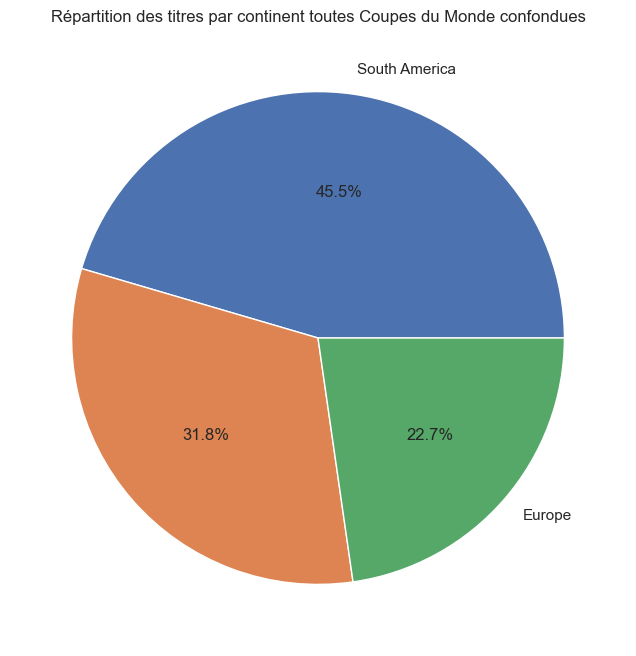

In [136]:
champions = (editions.join(
        teams,
        editions.champion == teams.team,
        "left"
    )
    .withColumn(
        "continent",
        mapping_expr[F.col("confederation")]
    )
)

continent_titles = (
    champions.groupBy("continent")
    .count()
    .orderBy(desc("count"))
)

pdf = pd.DataFrame(
    [row.asDict() for row in continent_titles.collect()]
)
plt.figure(figsize=(8, 8))
plt.pie(
    pdf["count"],
    labels=pdf["continent"],
    autopct="%1.1f%%"
)

plt.title("Répartition des titres par continent toutes Coupes du Monde confondues")
plt.show()

In [135]:
champions = (editions.join(
        teams,
        editions.champion == teams.team,
        "left"
    )
)

(champions.select("champion")
        .filter(champions
        .confederation.isNull())
        .distinct()
        .orderBy("champion")
        .show()
)


+------------+
|    champion|
+------------+
|       Italy|
|West Germany|
+------------+



## Evolution du nombre total de buts marqués par pays

In [40]:
matches.show()

+----+-------------+----------+------+------+--------------+------------------+----------+-------+----------+-------------------+
|year|        stage|     team1|score1|score2|         team2|             venue|      city|country|      date|              notes|
+----+-------------+----------+------+------+--------------+------------------+----------+-------+----------+-------------------+
|1930|  Group Stage|    France|     4|     1|        Mexico|Estadio Centenario|Montevideo|Uruguay|1930-07-13|First ever WC match|
|1930|  Group Stage|       USA|     3|     0|       Belgium|Estadio Centenario|Montevideo|Uruguay|1930-07-13|               NULL|
|1930|  Group Stage|Yugoslavia|     2|     1|        Brazil|Estadio Centenario|Montevideo|Uruguay|1930-07-14|               NULL|
|1930|  Group Stage|   Uruguay|     1|     0|          Peru|Estadio Centenario|Montevideo|Uruguay|1930-07-18|               NULL|
|1930|  Group Stage| Argentina|     6|     3|           USA|Estadio Centenario|Montevideo|

In [ ]:
matches.select("team1", "score1", "score2", "team2")

+----------+------+------+--------------+
|     team1|score1|score2|         team2|
+----------+------+------+--------------+
|    France|     4|     1|        Mexico|
|       USA|     3|     0|       Belgium|
|Yugoslavia|     2|     1|        Brazil|
|   Uruguay|     1|     0|          Peru|
| Argentina|     6|     3|           USA|
|   Uruguay|     6|     1|    Yugoslavia|
| Argentina|     6|     1|           USA|
|   Uruguay|     4|     2|     Argentina|
|     Italy|     7|     1|           USA|
|   Germany|     5|     2|       Belgium|
|     Italy|     1|     1|         Spain|
|     Italy|     1|     0|       Austria|
|   Germany|     3|     1|        Sweden|
|   Germany|     3|     2|       Austria|
|     Italy|     2|     1|Czechoslovakia|
|    Brazil|     6|     5|        Poland|
|     Italy|     2|     1|        Norway|
|    Brazil|     1|     1|Czechoslovakia|
|     Italy|     2|     1|        Brazil|
|   Hungary|     5|     1|        Sweden|
+----------+------+------+--------

In [56]:
# Buts marqués par l'équipe en position team1
goals_team1 = matches.select(
    F.col("team1").alias("country"),
    F.col("score1").alias("goals")
)

# Buts marqués par l'équipe en position team2
goals_team2 = matches.select(
    F.col("team2").alias("country"),
    F.col("score2").alias("goals")
)

# Regroupement et somme des buts
result = (
    goals_team1
    .union(goals_team2)
    .groupBy("country")
    .agg(F.sum("goals").alias("total_goals"))
    .where(F.col("total_goals") > 0)
    .orderBy(F.desc("total_goals"))
)

result.show()

+------------+-----------+
|     country|total_goals|
+------------+-----------+
|      Brazil|         89|
|      France|         55|
|     Germany|         52|
|   Argentina|         46|
|West Germany|         44|
|       Italy|         44|
|     Hungary|         31|
|     Uruguay|         27|
| Netherlands|         24|
|     England|         21|
|      Sweden|         16|
|      Russia|         14|
|    Portugal|         13|
|     Austria|         13|
|     Belgium|         12|
|     Croatia|         12|
|         USA|         12|
|       Spain|         11|
|    Bulgaria|         11|
|      Poland|         10|
+------------+-----------+
only showing top 20 rows


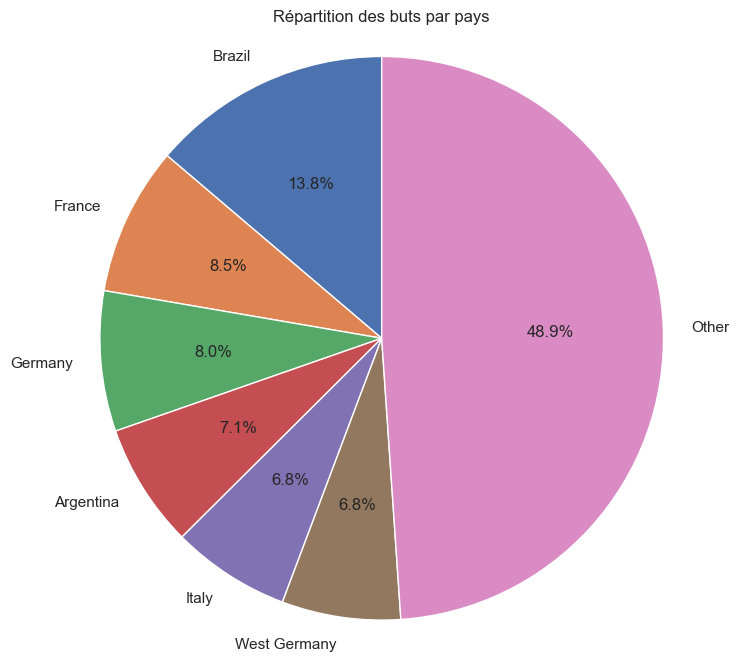

In [57]:
pdf =  pd.DataFrame(
    [row.asDict() for row in result.collect()]
)

# Pour mettre en valeur les pays qui ont le plus marqués
top6_countries_scorers = pdf.head(6)
other_goals = pdf.iloc[6:]["total_goals"].sum()

# Concaténation des top pays buteurs avec les autres pays buteurs moins représentatifs
pie_df = pd.concat([
    top6_countries_scorers,
    pd.DataFrame({
        "country": ["Other"],
        "total_goals": [other_goals]
    })
], ignore_index=True)

plt.figure(figsize=(8, 8))

plt.pie(
    pie_df["total_goals"],
    labels=pie_df["country"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des buts par pays")
plt.axis("equal")  # cercle parfait

plt.show()

## Top 10 des meilleurs buteurs de l'histoire en Coupe du Monde

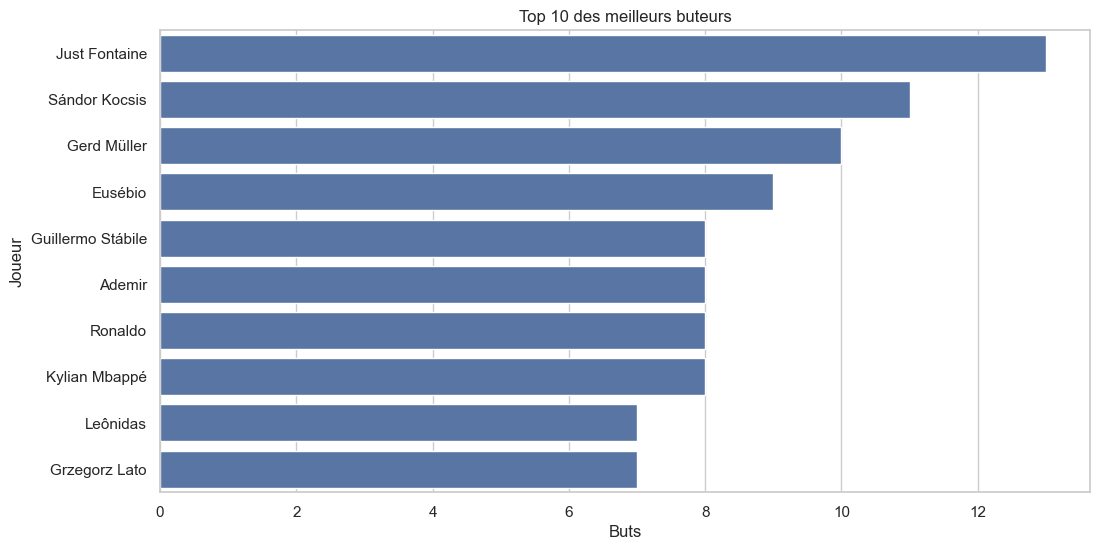

In [5]:
top10 = scorers.orderBy(desc("goals")).limit(10)

pdf = pd.DataFrame(
    [row.asDict() for row in top10.collect()]
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=pdf,
    x="goals",
    y="player"
)

plt.title("Top 10 des meilleurs buteurs")
plt.xlabel("Buts")
plt.ylabel("Joueur")
plt.show()